# 7. Model Evaluation

This notebook performs the final evaluation of the selected emotion classification model.

The final model was selected during hyperparameter tuning using only the training and validation datasets.

The untouched test dataset is now used to measure the final generalization performance of the selected model.

### Final Model

- Model: Linear Support Vector Machine
- C: 0.5
- Class weight: balanced

### Evaluation

The final model will be evaluated using:

- Accuracy
- Macro F1-score
- Weighted F1-score
- Per-emotion precision, recall, and F1-score
- Confusion matrix

The test results will not be used for further model selection or hyperparameter tuning.

In [1]:
import os
import joblib
import numpy as np

from scipy.sparse import load_npz

# Load final trained model
model_path = "../models/final_svm_model.pkl"
final_model = joblib.load(model_path)

# Load untouched test features and labels
X_test = load_npz("../data/processed/X_test_tfidf.npz")
y_test = np.load("../data/processed/y_test.npy")

print("Model loaded:", model_path)
print("Model file exists:", os.path.exists(model_path))

print("\nTest features:", X_test.shape)
print("Test labels:", y_test.shape)

print("\nModel type:", type(final_model))
print("Model C:", final_model.C)
print("Class weight:", final_model.class_weight)

Model loaded: ../models/final_svm_model.pkl
Model file exists: True

Test features: (2000, 32992)
Test labels: (2000,)

Model type: <class 'sklearn.svm._classes.LinearSVC'>
Model C: 0.5
Class weight: balanced


In [2]:
#  Generating Final Test Predictions

y_test_pred = final_model.predict(X_test)

print("Test predictions generated successfully.")
print("Number of predictions:", len(y_test_pred))
print("Number of test labels:", len(y_test))

print("\nFirst 20 predictions:")
print(y_test_pred[:20])

Test predictions generated successfully.
Number of predictions: 2000
Number of test labels: 2000

First 20 predictions:
[0 0 0 1 0 4 3 1 1 3 3 0 0 3 2 0 1 0 3 1]


In [3]:
#  Final Test Performance

from sklearn.metrics import accuracy_score, f1_score

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_weighted_f1 = f1_score(
    y_test,
    y_test_pred,
    average="weighted"
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print(f"Test Weighted F1: {test_weighted_f1:.4f}")

Test Accuracy: 0.8925
Test Macro F1: 0.8511
Test Weighted F1: 0.8940


In [4]:
#  Final Per-Emotion Performance

from sklearn.metrics import classification_report

emotion_names = [
    "sadness",
    "joy",
    "love",
    "anger",
    "fear",
    "surprise"
]

test_report = classification_report(
    y_test,
    y_test_pred,
    target_names=emotion_names,
    zero_division=0
)

print("Final Test Classification Report:")
print(test_report)

Final Test Classification Report:
              precision    recall  f1-score   support

     sadness       0.94      0.92      0.93       581
         joy       0.93      0.90      0.92       695
        love       0.72      0.85      0.78       159
       anger       0.88      0.90      0.89       275
        fear       0.88      0.85      0.87       224
    surprise       0.67      0.79      0.72        66

    accuracy                           0.89      2000
   macro avg       0.84      0.87      0.85      2000
weighted avg       0.90      0.89      0.89      2000



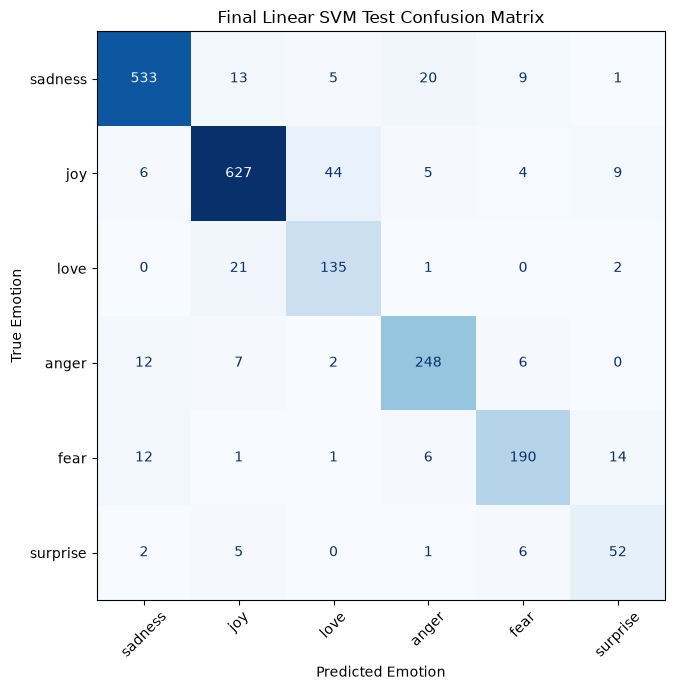

In [5]:
#  Final Test Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_test = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1, 2, 3, 4, 5]
)

fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=emotion_names
)

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues",
    colorbar=False
)

plt.title("Final Linear SVM Test Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
#  Exact Per-Class Prediction Counts

import pandas as pd
import numpy as np

class_counts = []

for label, emotion in enumerate(emotion_names):
    true_count = np.sum(y_test == label)
    correct_count = np.sum(
        (y_test == label) & (y_test_pred == label)
    )
    incorrect_count = true_count - correct_count

    class_counts.append({
        "Emotion": emotion,
        "Total Samples": true_count,
        "Correct": correct_count,
        "Incorrect": incorrect_count,
        "Recall": correct_count / true_count
    })

class_counts_df = pd.DataFrame(class_counts)

print(class_counts_df.to_string(index=False))

 Emotion  Total Samples  Correct  Incorrect   Recall
 sadness            581      533         48 0.917384
     joy            695      627         68 0.902158
    love            159      135         24 0.849057
   anger            275      248         27 0.901818
    fear            224      190         34 0.848214
surprise             66       52         14 0.787879


##  Final Model Evaluation Summary

The selected Linear SVM model was evaluated on the previously untouched test dataset.

The final model uses TF-IDF features with 32,992 dimensions and the following hyperparameters:

- Model: Linear Support Vector Machine
- C: 0.5
- Class weight: balanced

### Final Test Performance

- Accuracy: 89.25%
- Macro F1-score: 85.11%
- Weighted F1-score: 89.40%

The model achieved strong performance across the six emotion classes. Sadness and joy achieved the highest F1-scores, while surprise was the most challenging class.

The difference between validation and test performance was moderate, indicating that the model generalizes reasonably well to unseen data.

The confusion matrix showed that the most notable classification challenges involve semantically similar emotions, particularly love, joy, fear, and surprise.

The test dataset was used only for final evaluation and was not used for model selection or hyperparameter tuning.

Overall, the TF-IDF + Linear SVM approach provides a strong classical machine learning baseline for text emotion detection.

In [7]:
# Save final evaluation metrics

final_metrics = {
    "Model": "Linear SVM",
    "C": 0.5,
    "Class Weight": "balanced",
    "Test Accuracy": test_accuracy,
    "Test Macro F1": test_macro_f1,
    "Test Weighted F1": test_weighted_f1
}

final_metrics_df = pd.DataFrame([final_metrics])

results_path = "../models/final_evaluation_results.csv"

final_metrics_df.to_csv(
    results_path,
    index=False
)

print("Final evaluation results saved:", results_path)
print("File exists:", os.path.exists(results_path))

print("\nFinal Evaluation:")
print(final_metrics_df.to_string(index=False))

Final evaluation results saved: ../models/final_evaluation_results.csv
File exists: True

Final Evaluation:
     Model   C Class Weight  Test Accuracy  Test Macro F1  Test Weighted F1
Linear SVM 0.5     balanced         0.8925       0.851075           0.89401


### Sample Prediction

In [10]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\SINAN P SALIM\OneDrive\Desktop\Project\text-emotion-detection


In [11]:
from src.predict import predict_emotion

print("predict.py imported successfully!")

predict.py imported successfully!


In [12]:
test_texts = [
    "I am feeling very happy today",
    "I feel really sad and hopeless",
    "I am extremely angry about what happened",
    "I am scared and worried",
    "I love spending time with this person",
    "I cannot believe what just happened"
]

for text in test_texts:
    prediction = predict_emotion(text)

    print("Text:", text)
    print("Predicted emotion:", prediction)
    print("-" * 60)

Text: I am feeling very happy today
Predicted emotion: joy
------------------------------------------------------------
Text: I feel really sad and hopeless
Predicted emotion: sadness
------------------------------------------------------------
Text: I am extremely angry about what happened
Predicted emotion: anger
------------------------------------------------------------
Text: I am scared and worried
Predicted emotion: fear
------------------------------------------------------------
Text: I love spending time with this person
Predicted emotion: joy
------------------------------------------------------------
Text: I cannot believe what just happened
Predicted emotion: sadness
------------------------------------------------------------
